In [1]:
import random
from pathlib import Path

import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# Make plots a bit nicer
plt.rcParams["figure.dpi"] = 120

# Adjust if you run the notebook from a different folder
PROJECT_ROOT = Path.cwd().parent

IAM_META_PATH = PROJECT_ROOT / "data" / "processed" / "metadata" / "iam_metadata.csv"
EMURU_SENT_META_PATH = PROJECT_ROOT / "data" / "processed" / "metadata" / "emuru_sentences_metadata.csv"
EMURU_WORD_META_PATH = PROJECT_ROOT / "data" / "processed" / "metadata" / "emuru_words_metadata.csv"
EMURU_FAIL_META_PATH = PROJECT_ROOT / "data" / "processed" / "metadata" / "emuru_failures_metadata.csv"

EMURU_SENTENCES_DIR = PROJECT_ROOT / "data" / "raw" / "emuru" / "sentences"

IAM_META_PATH, EMURU_SENT_META_PATH, EMURU_SENTENCES_DIR

(PosixPath('/home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/data/processed/metadata/iam_metadata.csv'),
 PosixPath('/home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/data/processed/metadata/emuru_sentences_metadata.csv'),
 PosixPath('/home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/data/raw/emuru/sentences'))

In [2]:
iam_df = pd.read_csv(IAM_META_PATH)
emuru_sent_df = pd.read_csv(EMURU_SENT_META_PATH)

print("IAM shape:", iam_df.shape)
print("Emuru sentences shape:", emuru_sent_df.shape)

# Optional: load words / failures if they exist
if EMURU_WORD_META_PATH.exists():
    emuru_word_df = pd.read_csv(EMURU_WORD_META_PATH)
    print("Emuru words shape:", emuru_word_df.shape)
else:
    emuru_word_df = None
    print("No emuru_words_metadata.csv found.")

if EMURU_FAIL_META_PATH.exists():
    emuru_fail_df = pd.read_csv(EMURU_FAIL_META_PATH)
    print("Failures shape:", emuru_fail_df.shape)
else:
    emuru_fail_df = None
    print("No emuru_failures_metadata.csv found.")


IAM shape: (10373, 6)
Emuru sentences shape: (9801, 7)
Emuru words shape: (45115, 7)
Failures shape: (589, 8)


In [35]:
# Unique IAM lines in each table
n_iam_total = iam_df["filepath"].nunique()
n_iam_with_emuru = emuru_sent_df["iam_filepath"].nunique()

print(f"Total IAM lines (unique filepath): {n_iam_total}")
print(f"IAM lines with Emuru sentence:     {n_iam_with_emuru}")
print(f"Coverage: {n_iam_with_emuru / n_iam_total:.2%}")

if emuru_fail_df is not None:
    n_iam_failed = emuru_fail_df["iam_filepath"].nunique()
    print(f"IAM lines marked as failed:        {n_iam_failed}")


Total IAM lines (unique filepath): 10373
IAM lines with Emuru sentence:     9801
Coverage: 94.49%
IAM lines marked as failed:        589


In [36]:
def check_sentence_files_exist(df, project_root: Path):
    missing = []
    for idx, row in df.iterrows():
        rel_path = Path(row["emuru_sentence_filepath"])
        abs_path = project_root / rel_path
        if not abs_path.exists():
            missing.append((idx, str(rel_path)))
    return missing

missing_sentence_files = check_sentence_files_exist(emuru_sent_df, PROJECT_ROOT)
print(f"Sentence images referenced in metadata: {len(emuru_sent_df)}")
print(f"Missing sentence image files:           {len(missing_sentence_files)}")

if missing_sentence_files[:10]:
    print("First few missing examples:")
    for i, p in missing_sentence_files[:10]:
        print(f"  row {i}: {p}")


Sentence images referenced in metadata: 9801
Missing sentence image files:           0


In [37]:
all_on_disk = sorted(EMURU_SENTENCES_DIR.glob("*.png"))

meta_paths = set(
    (PROJECT_ROOT / Path(p)).resolve()
    for p in emuru_sent_df["emuru_sentence_filepath"].astype(str)
)

orphans = [p for p in all_on_disk if p.resolve() not in meta_paths]

print(f"Sentence images on disk:       {len(all_on_disk)}")
print(f"Sentence images in metadata:   {len(meta_paths)}")
print(f"Orphan sentence images (no CSV row): {len(orphans)}")

# Show a few orphan filenames if any
for p in orphans[:10]:
    print("  orphan:", p.relative_to(PROJECT_ROOT))


Sentence images on disk:       9851
Sentence images in metadata:   9801
Orphan sentence images (no CSV row): 50
  orphan: data/raw/emuru/sentences/iam_00144_sentence.png
  orphan: data/raw/emuru/sentences/iam_00275_sentence.png
  orphan: data/raw/emuru/sentences/iam_00312_sentence.png
  orphan: data/raw/emuru/sentences/iam_00341_sentence.png
  orphan: data/raw/emuru/sentences/iam_00368_sentence.png
  orphan: data/raw/emuru/sentences/iam_00397_sentence.png
  orphan: data/raw/emuru/sentences/iam_00428_sentence.png
  orphan: data/raw/emuru/sentences/iam_00475_sentence.png
  orphan: data/raw/emuru/sentences/iam_00543_sentence.png
  orphan: data/raw/emuru/sentences/iam_00562_sentence.png


          text_len   num_chunks
count  9801.000000  9801.000000
mean     43.541271     4.603102
std      10.245056     1.292761
min       1.000000     1.000000
25%      38.000000     4.000000
50%      43.000000     5.000000
75%      50.000000     5.000000
max      84.000000    11.000000


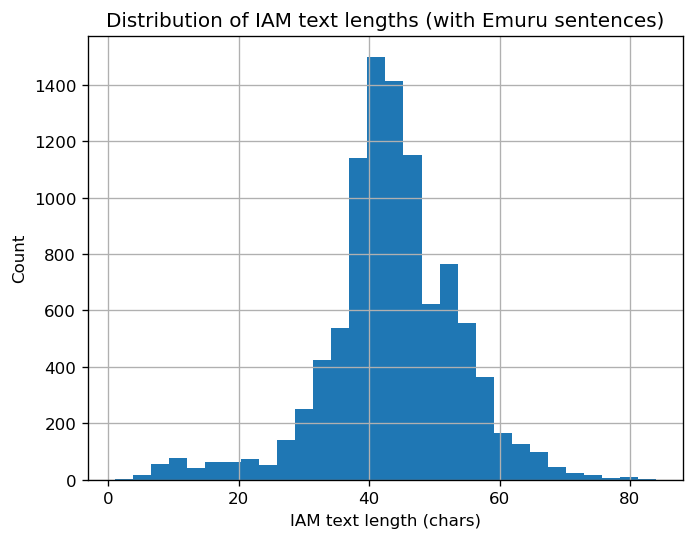

IAM paths referenced in Emuru sentences: 9801
IAM paths not found in iam_metadata:     0


In [38]:
# Number of chunks vs text length
emuru_sent_df["text_len"] = emuru_sent_df["iam_text"].str.len()
emuru_sent_df["num_chunks"] = emuru_sent_df["num_chunks"].astype(int)

print(emuru_sent_df[["text_len", "num_chunks"]].describe())

# Quick histogram of text lengths
emuru_sent_df["text_len"].hist(bins=30)
plt.xlabel("IAM text length (chars)")
plt.ylabel("Count")
plt.title("Distribution of IAM text lengths (with Emuru sentences)")
plt.show()

# Check that every emuru iam_filepath exists in iam_df
iam_paths_set = set(iam_df["filepath"].astype(str))
missing_iam_meta = [
    p for p in emuru_sent_df["iam_filepath"].astype(str)
    if p not in iam_paths_set
]

print(f"IAM paths referenced in Emuru sentences: {emuru_sent_df['iam_filepath'].nunique()}")
print(f"IAM paths not found in iam_metadata:     {len(missing_iam_meta)}")
if missing_iam_meta[:10]:
    print("First missing IAM paths:")
    for p in missing_iam_meta[:10]:
        print("  ", p)


In [39]:
from PIL import ImageFilter

def sharpen_image(img: Image.Image,
                  radius: float = 1.0,
                  percent: int = 150,
                  threshold: int = 3) -> Image.Image:
    """Sharpen an image using an unsharp mask."""
    return img.filter(ImageFilter.UnsharpMask(
        radius=radius,
        percent=percent,
        threshold=threshold,
    ))


In [40]:
def load_iam_image(iam_rel_path: str | Path) -> Image.Image:
    """Load IAM image using filepath relative to project root."""
    abs_path = PROJECT_ROOT / Path(iam_rel_path)
    return Image.open(abs_path).convert("RGB")


def load_emuru_sentence_image(sent_rel_path: str | Path) -> Image.Image:
    """Load Emuru sentence image using filepath relative to project root."""
    abs_path = PROJECT_ROOT / Path(sent_rel_path)
    return Image.open(abs_path).convert("RGB")



def show_vertical_comparison(row, show_title: bool = True):
    """
    Show text + IAM image + Emuru sentence image vertically.
    
    `row` is a row from emuru_sent_df.
    """
    text = row["iam_text"]
    iam_rel = row["iam_filepath"]
    emuru_rel = row["emuru_sentence_filepath"]

    print("=" * 80)
    print("IAM index:", row.get("iam_index", "N/A"))
    print("IAM filepath:", iam_rel)
    print("Emuru sentence filepath:", emuru_rel)
    print("\nTEXT:")
    print(text)
    print("=" * 80)

    iam_img = load_iam_image(iam_rel)
    emuru_img = load_emuru_sentence_image(emuru_rel)

    # Make heights comparable but keep aspect ratio
    target_width = 800
    def resize_keep_aspect(img, target_w):
        w, h = img.size
        if w == 0:
            return img
        new_h = int(h * (target_w / w))
        return img.resize((target_w, new_h))

    iam_img_resized = resize_keep_aspect(iam_img, target_width)
    emuru_img_resized = resize_keep_aspect(emuru_img, target_width)

    # Sharpened Emuru
    emuru_sharp = sharpen_image(emuru_img, radius=1.0, percent=180, threshold=3)
    emuru_sharp_resized = resize_keep_aspect(emuru_sharp, target_width)

    # Create vertical figure: IAM / Emuru / Emuru-sharp
    fig, axes = plt.subplots(3, 1, figsize=(8, 7))

    axes[0].imshow(iam_img_resized)
    axes[0].set_title("Original IAM line")
    axes[0].axis("off")

    axes[1].imshow(emuru_img_resized)
    axes[1].set_title("Emuru generated sentence (original)")
    axes[1].axis("off")

    axes[2].imshow(emuru_sharp_resized)
    axes[2].set_title("Emuru generated sentence (sharpened)")
    axes[2].axis("off")

    plt.subplots_adjust(hspace=0.02)
    plt.show()



IAM index: 1995
IAM filepath: data/raw/iam/iam_01995.png
Emuru sentence filepath: data/raw/emuru/sentences/iam_01995_sentence.png

TEXT:
happen . THE UN's ability to keep peace depends


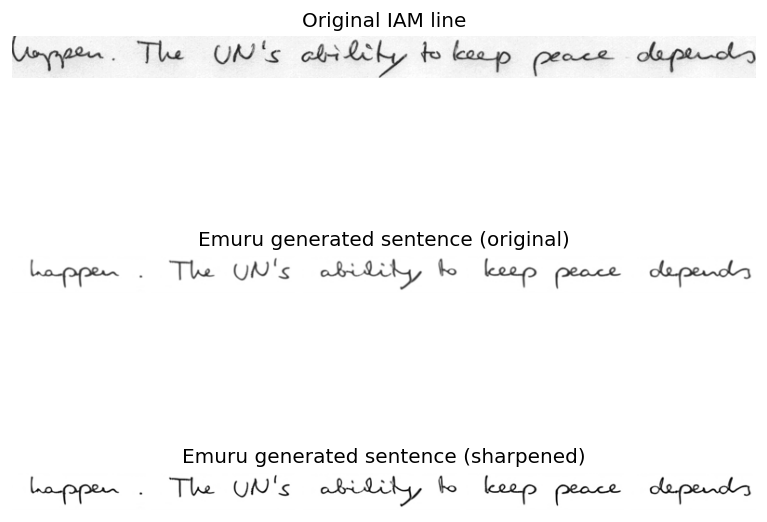

IAM index: 448
IAM filepath: data/raw/iam/iam_00448.png
Emuru sentence filepath: data/raw/emuru/sentences/iam_00448_sentence.png

TEXT:
to angry uproar . One dealt with the human


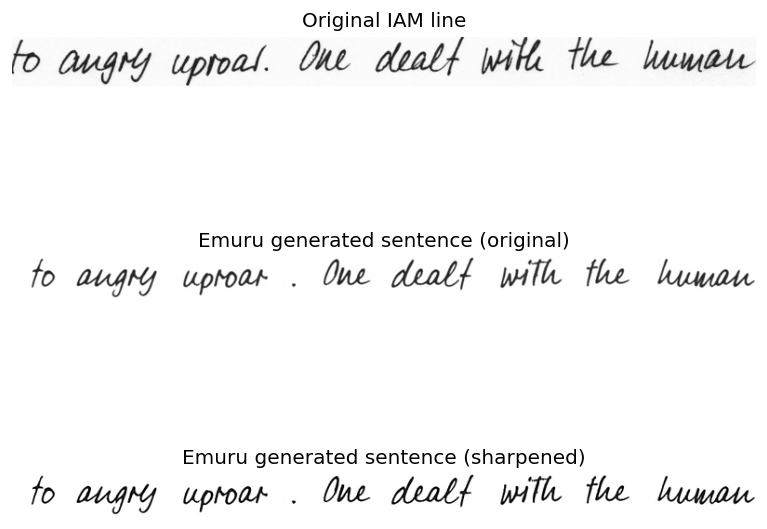

IAM index: 4777
IAM filepath: data/raw/iam/iam_04777.png
Emuru sentence filepath: data/raw/emuru/sentences/iam_04777_sentence.png

TEXT:
Good Intent , a public-house in Walworth . Her day


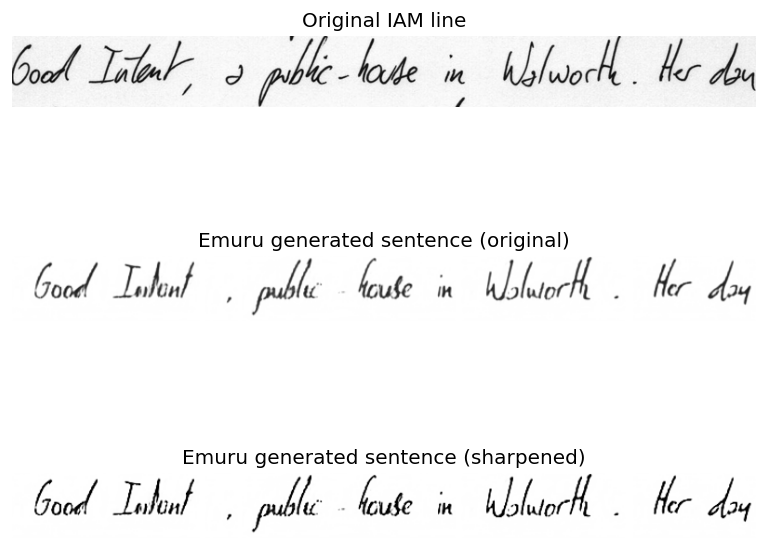

IAM index: 4271
IAM filepath: data/raw/iam/iam_04271.png
Emuru sentence filepath: data/raw/emuru/sentences/iam_04271_sentence.png

TEXT:
frame that will sit firmly on


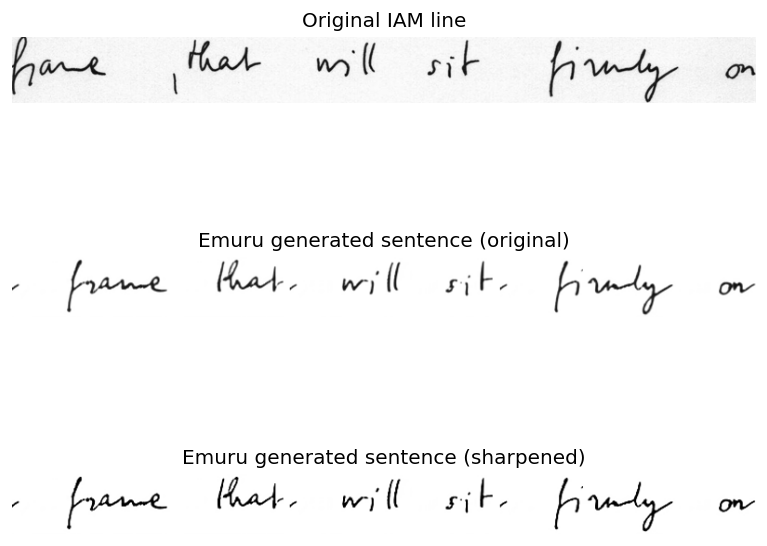

IAM index: 3895
IAM filepath: data/raw/iam/iam_03895.png
Emuru sentence filepath: data/raw/emuru/sentences/iam_03895_sentence.png

TEXT:
She thrust out her hand - and felt


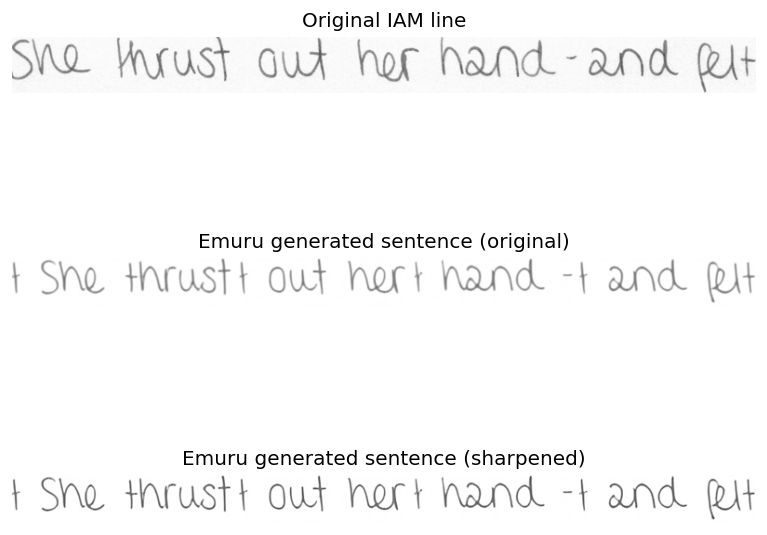

IAM index: 2472
IAM filepath: data/raw/iam/iam_02472.png
Emuru sentence filepath: data/raw/emuru/sentences/iam_02472_sentence.png

TEXT:
than it takes to say " Tolpuddle


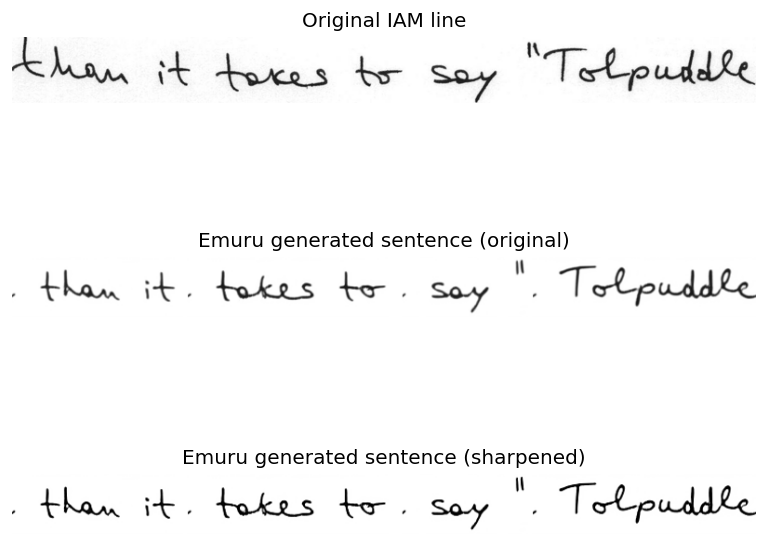

IAM index: 1828
IAM filepath: data/raw/iam/iam_01828.png
Emuru sentence filepath: data/raw/emuru/sentences/iam_01828_sentence.png

TEXT:
contingency would be to sign a peace treaty to remove the cancerous


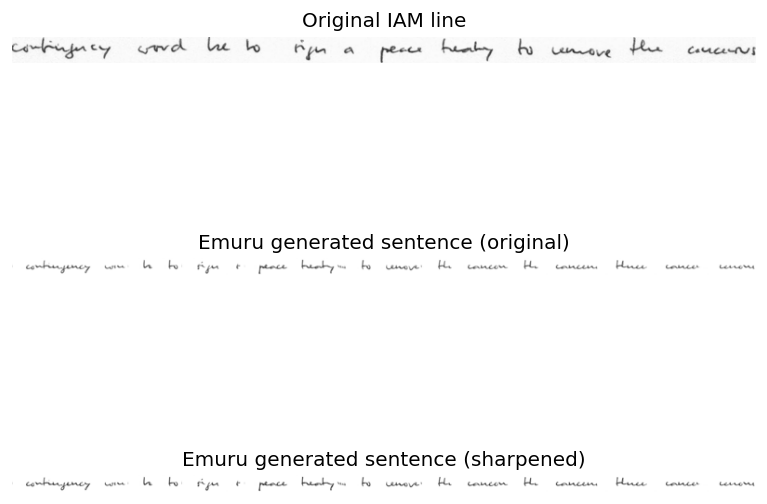

IAM index: 9452
IAM filepath: data/raw/iam/iam_09452.png
Emuru sentence filepath: data/raw/emuru/sentences/iam_09452_sentence.png

TEXT:
scanner could be adjusted to cover any


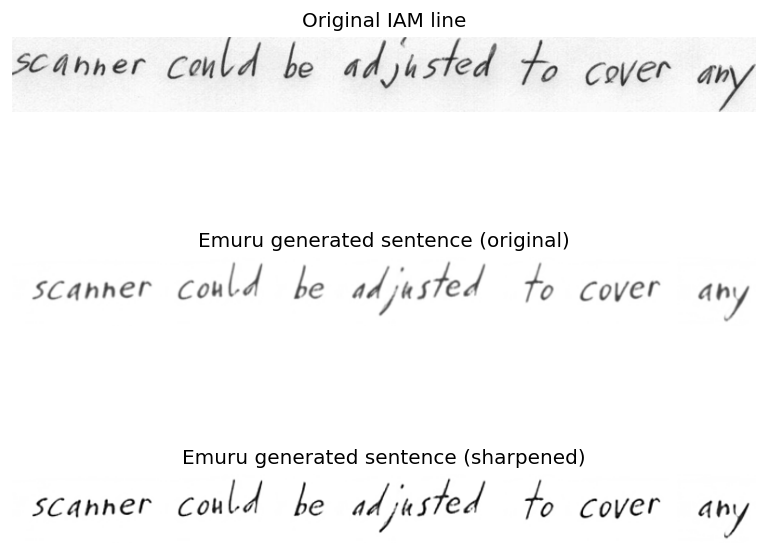

In [41]:
# For reproducibility
random.seed(42)

n_examples = 8  # change as you like
indices = random.sample(range(len(emuru_sent_df)), k=min(n_examples, len(emuru_sent_df)))

for idx in indices:
    row = emuru_sent_df.iloc[idx]
    show_vertical_comparison(row)


In [10]:
from PIL import ImageFilter

def sharpen_image(img: Image.Image,
                  radius: float = 1.0,
                  percent: int = 150,
                  threshold: int = 3) -> Image.Image:
    """
    Sharpen an image using an unsharp mask.
    """
    return img.filter(ImageFilter.UnsharpMask(
        radius=radius,
        percent=percent,
        threshold=threshold,
    ))


In [11]:
from IPython.display import display

def load_emuru_sentence_image(sent_rel_path: str | Path) -> Image.Image:
    abs_path = PROJECT_ROOT / Path(sent_rel_path)
    return Image.open(abs_path).convert("RGB")


def show_sharpening_effect(row,
                           radius: float = 1.0,
                           percent: int = 180,
                           threshold: int = 3):
    """
    Visualise sharpening on a single Emuru sentence image.
    Shows original + sharpened.
    """
    emuru_rel = row["emuru_sentence_filepath"]
    text = row["iam_text"]

    print("=" * 100)
    print("IAM index:", row.get("iam_index", "N/A"))
    print("Emuru sentence filepath:", emuru_rel)
    print("\nTEXT:")
    print(text)
    print("=" * 100)

    img = load_emuru_sentence_image(emuru_rel)

    # Resize for nicer viewing in notebook
    target_width = 900
    def resize_keep_aspect(im, target_w):
        w, h = im.size
        if w == 0:
            return im
        new_h = int(h * (target_w / w))
        return im.resize((target_w, new_h))

    img_orig = resize_keep_aspect(img, target_width)
    img_sharp = resize_keep_aspect(
        sharpen_image(img, radius=radius, percent=percent, threshold=threshold),
        target_width
    )

    print("Original Emuru image:")
    display(img_orig)

    print(f"Sharpened Emuru image (radius={radius}, percent={percent}, threshold={threshold}):")
    display(img_sharp)


IAM index: 2854
Emuru sentence filepath: data/raw/emuru/sentences/iam_02854_sentence.png

TEXT:
leaves one a little breathless .
Original Emuru image:


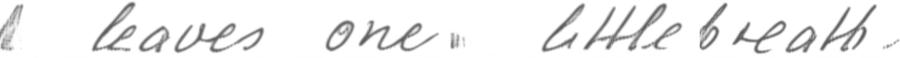

Sharpened Emuru image (radius=1.0, percent=180, threshold=3):


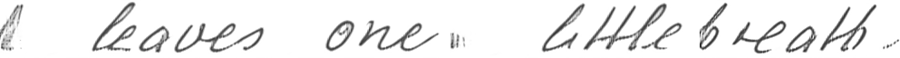

IAM index: 1316
Emuru sentence filepath: data/raw/emuru/sentences/iam_01316_sentence.png

TEXT:
the protests and these should carry weight with
Original Emuru image:


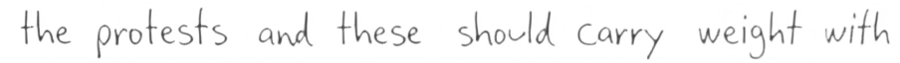

Sharpened Emuru image (radius=1.0, percent=180, threshold=3):


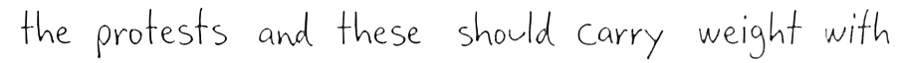

IAM index: 3455
Emuru sentence filepath: data/raw/emuru/sentences/iam_03455_sentence.png

TEXT:
Mr. William Lucas ( Morris ) is always insensitively
Original Emuru image:


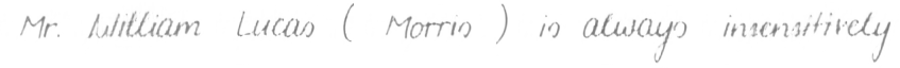

Sharpened Emuru image (radius=1.0, percent=180, threshold=3):


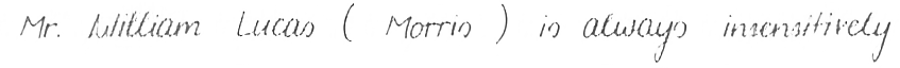

In [12]:
import random

random.seed(7)
n_examples = 3

indices = random.sample(range(len(emuru_sent_df)), k=min(n_examples, len(emuru_sent_df)))
for idx in indices:
    row = emuru_sent_df.iloc[idx]
    show_sharpening_effect(row, radius=1.0, percent=180, threshold=3)


## Figure 0 — IAM vs Emuru variants (Baseline, A4, A5)

Each row is one IAM line. Columns show the genuine IAM image and the three Emuru variants side by side.

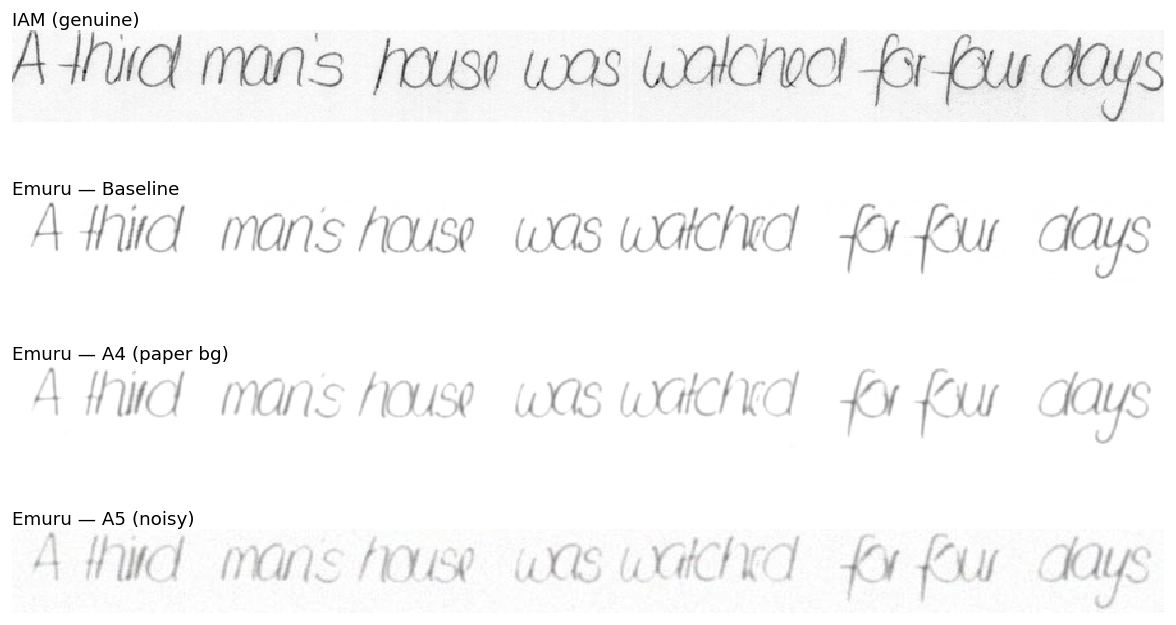


Saved combined figure to: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/notebooks/figure0_iam_00773.png


In [38]:
# iam_00773 across all four variants composed into a SINGLE figure,
# white background, tight spacing, no caption. Saved as one PNG file.
IAM_DIR             = PROJECT_ROOT / "data" / "raw" / "iam"
EMURU_BASELINE_DIR  = PROJECT_ROOT / "data" / "raw" / "emuru" / "sentences"
EMURU_A4_DIR        = PROJECT_ROOT / "data" / "raw" / "emuru_A4"
EMURU_A5_DIR        = PROJECT_ROOT / "data" / "raw" / "emuru_A5_noisy"

TARGET_WIDTH = 900
OUT_PATH = PROJECT_ROOT / "notebooks" / "figure0_iam_00773.png"


def variant_paths(iam_index: int) -> dict[str, Path]:
    return {
        "IAM (genuine)":          IAM_DIR            / f"iam_{iam_index:05d}.png",
        "Emuru — Baseline":       EMURU_BASELINE_DIR / f"iam_{iam_index:05d}_sentence.png",
        "Emuru — A4 (paper bg)":  EMURU_A4_DIR       / f"iam_{iam_index:05d}_sentence.png",
        "Emuru — A5 (noisy)":     EMURU_A5_DIR       / f"iam_{iam_index:05d}_sentence_A5noisy.png",
    }


def resize_to_width(img: Image.Image, target_w: int) -> Image.Image:
    w, h = img.size
    new_h = int(round(h * (target_w / w)))
    return img.resize((target_w, new_h), Image.LANCZOS)


def flatten_to_white(img: Image.Image) -> Image.Image:
    if img.mode in ("RGBA", "LA") or (img.mode == "P" and "transparency" in img.info):
        img = img.convert("RGBA")
        white = Image.new("RGBA", img.size, (255, 255, 255, 255))
        return Image.alpha_composite(white, img).convert("RGB")
    return img.convert("RGB")


selected_idx = 773
paths = variant_paths(selected_idx)
items = list(paths.items())

missing = [str(p) for p in paths.values() if not p.exists()]
assert not missing, f"Missing variant files for iam_{selected_idx:05d}: {missing}"

fig, axes = plt.subplots(len(items), 1, figsize=(10, 1.4 * len(items)), facecolor="white")
for ax, (label, p) in zip(axes, items):
    img = resize_to_width(flatten_to_white(Image.open(p)), TARGET_WIDTH)
    ax.imshow(img, interpolation="none")
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(label, fontsize=11, loc="left", pad=2)

fig.subplots_adjust(hspace=0.15, top=0.97, bottom=0.02, left=0.02, right=0.98)

fig.savefig(OUT_PATH, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

print(f"\nSaved combined figure to: {OUT_PATH}")